In [1]:
# import os
# from google.colab import drive

# drive.mount('/content/drive')

# BASE = '/content/drive/MyDrive/AI_BaiTapLon/cccd_extraction_src'

# label_dir = os.path.join(
#     BASE,
#     'data/detection/labels/train/Tu'
# )

# for filename in os.listdir(label_dir):

#     if filename.endswith('.txt'):

#         # Lấy phần tên cuối: cccd_0048.txt
#         new_name = filename[-13:]

#         old_path = os.path.join(label_dir, filename)
#         new_path = os.path.join(label_dir, new_name)

#         os.rename(old_path, new_path)

#         print(f'{filename} -> {new_name}')

# print('Rename hoàn tất!')

Mounted at /content/drive
1d512671__Tu%5Ccccd_0002.txt -> cccd_0002.txt
d102656d__Tu%5Ccccd_0003.txt -> cccd_0003.txt
b467221c__Tu%5Ccccd_0005.txt -> cccd_0005.txt
90b40178__Tu%5Ccccd_0001.txt -> cccd_0001.txt
394f7cfd__Tu%5Ccccd_0006.txt -> cccd_0006.txt
dceb8fcf__Tu%5Ccccd_0007.txt -> cccd_0007.txt
9d17f4d8__Tu%5Ccccd_0004.txt -> cccd_0004.txt
56108be0__Tu%5Ccccd_0116.txt -> cccd_0116.txt
a86188d4__Tu%5Ccccd_0106.txt -> cccd_0106.txt
63ac3c98__Tu%5Ccccd_0041.txt -> cccd_0041.txt
93a61cd1__Tu%5Ccccd_0073.txt -> cccd_0073.txt
7ad3718f__Tu%5Ccccd_0169.txt -> cccd_0169.txt
961946c9__Tu%5Ccccd_0185.txt -> cccd_0185.txt
787e5313__Tu%5Ccccd_0056.txt -> cccd_0056.txt
61b7379d__Tu%5Ccccd_0210.txt -> cccd_0210.txt
f9d9ba60__Tu%5Ccccd_0089.txt -> cccd_0089.txt
693f84ce__Tu%5Ccccd_0121.txt -> cccd_0121.txt
ef4ca21b__Tu%5Ccccd_0104.txt -> cccd_0104.txt
9611051e__Tu%5Ccccd_0110.txt -> cccd_0110.txt
31956459__Tu%5Ccccd_0016.txt -> cccd_0016.txt
2d49cbe4__Tu%5Ccccd_0194.txt -> cccd_0194.txt
a299d16f

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ảnh: cccd_0016.jpg
Label: cccd_0016.txt


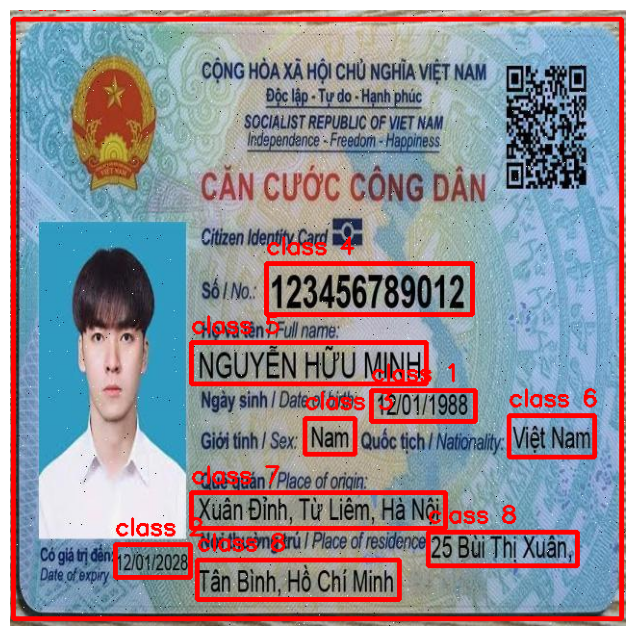

In [4]:
import os
import cv2
import random
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/AI_BaiTapLon/cccd_extraction_src'

# Folder ảnh và label
image_dir = os.path.join(BASE, 'data/detection/images/train/Tu')
label_dir = os.path.join(BASE, 'data/detection/labels/train/Tu')

# Lấy danh sách ảnh
image_files = [
    f for f in os.listdir(image_dir)
    if f.endswith(('.jpg', '.jpeg', '.png'))
]

# Random 1 ảnh để kiểm tra
image_name = random.choice(image_files)

# Tên label tương ứng
label_name = os.path.splitext(image_name)[0] + '.txt'

image_path = os.path.join(image_dir, image_name)
label_path = os.path.join(label_dir, label_name)

print("Ảnh:", image_name)
print("Label:", label_name)

# Đọc ảnh
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

# Đọc label YOLO
if os.path.exists(label_path):

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:

        cls, x_center, y_center, bw, bh = map(float, line.strip().split())

        # Convert YOLO -> pixel
        x_center *= w
        y_center *= h
        bw *= w
        bh *= h

        x1 = int(x_center - bw / 2)
        y1 = int(y_center - bh / 2)

        x2 = int(x_center + bw / 2)
        y2 = int(y_center + bh / 2)

        # Vẽ bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 3)

        # Hiện class id
        cv2.putText(
            image,
            f'class {int(cls)}',
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2
        )

else:
    print("Không tìm thấy label!")

# Hiển thị ảnh
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis('off')
plt.show()